# Computer Exercise 7.2 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 7.2 Runge–Kutta Methods — *Heun (RK2)와 Midpoint (RK2): Taylor 2차의 두 얼굴*
> **풀이 일자**: Day 28
> **언어**: Python 3 (NumPy / SciPy / Matplotlib)


## 1. 문제 (원문)

> **1.** Implement the 2nd-order Runge–Kutta methods (Heun's method and the
> explicit midpoint method) for the initial-value problem
> $y' = -y, \; y(0) = 1$ on $[0, 1]$. Verify numerically that both methods are
> 2nd-order accurate by tabulating the global error at $t = 1$ for a sequence
> of halved step sizes, and discuss why two *different* schemes share the
> same order.

### 한국어 풀이용 정리
Day 27 의 *Taylor 점화식*에서는 $y''$, $y'''$ 같은 *고차 도함수를 손으로 유도*해야 했다. RK2 는
같은 차수 ($\mathcal{O}(h^2)$) 를 **함수 평가만으로** — 도함수 없이 — 얻어내는 첫 번째 trick.
"같은 차수의 RK 가족이 여럿 존재한다" 는 사실 (Heun과 midpoint) 까지 확인한다.


## 2. 수학적 배경

### 2.1 일반 RK2 의 *둘 자유도* 와 *세 조건*
명시적 2-stage RK 의 일반형은

$$
\begin{aligned}
k_1 &= f(t_n,\,y_n), \\
k_2 &= f\big(t_n + c_2 h,\; y_n + h\,a_{21}\,k_1\big), \\
y_{n+1} &= y_n + h(b_1 k_1 + b_2 k_2).
\end{aligned}
$$

Taylor 전개

$$
y(t_n + h) = y_n + h y' + \tfrac{h^2}{2} y'' + \mathcal{O}(h^3),
\quad y'' = f_t + f_y f
$$

와 *수치해의 Taylor 전개*

$$
y_{n+1} = y_n + h(b_1 + b_2) f + h^2 b_2 (c_2 f_t + a_{21} f_y f) + \mathcal{O}(h^3)
$$

를 항별로 맞추면 **2차 RK 의 order-2 조건**

$$
\boxed{\; b_1 + b_2 = 1, \quad b_2 c_2 = \tfrac{1}{2}, \quad b_2 a_{21} = \tfrac{1}{2}. \;}
$$

→ 미지수 4개($b_1, b_2, c_2, a_{21}$), 식 3개 → **1-매개변수 가족**.

### 2.2 두 표준 선택
| 이름 | $c_2$ | $a_{21}$ | $b_1$ | $b_2$ | 형태 |
|---|---|---|---|---|---|
| **Heun (explicit trapezoidal)** | 1 | 1 | $\tfrac{1}{2}$ | $\tfrac{1}{2}$ | $y_{n+1} = y_n + \tfrac{h}{2}(k_1 + k_2)$ |
| **Midpoint** | $\tfrac{1}{2}$ | $\tfrac{1}{2}$ | 0 | 1 | $y_{n+1} = y_n + h\,k_2$ |

둘 다 *동일한 차수* 의 *동일한 주도 오차 항*($\mathcal O(h^3)$의 *계수*는 다름)을 가진다.

### 2.3 전역 오차의 차수

$$
\boxed{\; \|y_N - y(T)\| = \mathcal{O}(h^p), \quad p = 2 \quad (\text{RK2}). \;}
$$

→ 스텝을 절반으로 줄이면 오차는 약 $1/4$. 인접 비율이 $\to 4$ 임을 표로 확인하는 것이 오늘의 *결정적 증거*.


## 3. 풀이 흐름

1. 시험 IVP $y' = -y, \; y(0)=1$ 의 *해석해* $y(t) = e^{-t}$ 로 참값 확보.
2. 일반 explicit-RK2 루틴 작성 — Butcher tableau $(c_2, a_{21}, b_1, b_2)$ 만 바꿔서 두 방식 모두 같은 함수로.
3. $h = 2^{-k}, \; k = 2, 3, \ldots, 16$ 에 대해 $t = 1$ 에서의 전역 오차 $|y_N - e^{-1}|$ 측정.
4. *인접 비율* $E(h)/E(h/2)$ 를 표에 — 두 방식 모두 $\to 4$ 인지 확인.
5. log–log 그림에서 두 방식의 오차곡선을 같이 — 기울기 +2 의 두 직선, 그리고 round-off 한계.
6. *경험 기울기* $\widehat{p}$ 를 polyfit 으로 측정 → $\widehat{p} \approx 2.00$.
7. 결론: *둘은 같은 차수이지만 상수만 다른 형제* — RK 가족의 *자유도* 시각화.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def rk2_step(f, t, y, h, c2, a21, b1, b2):
    k1 = f(t, y)
    k2 = f(t + c2 * h, y + h * a21 * k1)
    return y + h * (b1 * k1 + b2 * k2)


def integrate_rk2(f, t0, y0, T, h, tableau):
    c2, a21, b1, b2 = tableau
    n = int(round((T - t0) / h))
    t, y = t0, y0
    for _ in range(n):
        y = rk2_step(f, t, y, h, c2, a21, b1, b2)
        t += h
    return y


# y' = -y, y(0) = 1, true y(1) = exp(-1)
f = lambda t, y: -y
T, y0, true_y = 1.0, 1.0, np.exp(-1.0)

HEUN = (1.0, 1.0, 0.5, 0.5)
MID = (0.5, 0.5, 0.0, 1.0)

ks = np.arange(2, 17)
hs = 2.0 ** (-ks.astype(float))

rows = []
for h in hs:
    y_h = integrate_rk2(f, 0.0, y0, T, h, HEUN)
    y_m = integrate_rk2(f, 0.0, y0, T, h, MID)
    rows.append({
        "k": int(round(-np.log2(h))),
        "h": h,
        "err_Heun": abs(y_h - true_y),
        "err_Mid":  abs(y_m - true_y),
    })

df = pd.DataFrame(rows)
df["ratio_Heun"] = df["err_Heun"].shift(1) / df["err_Heun"]
df["ratio_Mid"]  = df["err_Mid"].shift(1)  / df["err_Mid"]
pd.set_option("display.float_format", lambda v: f"{v:.3e}")
df


,k,h,err_Heun,err_Mid,ratio_Heun,ratio_Mid
0,2,2.500e-01,4.650e-03,4.650e-03,NaN,NaN
1,3,1.250e-01,1.054e-03,1.054e-03,4.412e+00,4.412e+00
2,4,6.250e-02,2.511e-04,2.511e-04,4.197e+00,4.197e+00
3,5,3.125e-02,6.130e-05,6.130e-05,4.096e+00,4.096e+00
4,6,1.562e-02,1.515e-05,1.515e-05,4.047e+00,4.047e+00
5,7,7.812e-03,3.764e-06,3.764e-06,4.024e+00,4.024e+00
6,8,3.906e-03,9.383e-07,9.383e-07,4.012e+00,4.012e+00
7,9,1.953e-03,2.342e-07,2.342e-07,4.006e+00,4.006e+00
8,10,9.766e-04,5.852e-08,5.852e-08,4.003e+00,4.003e+00
9,11,4.883e-04,1.462e-08,1.462e-08,4.001e+00,4.001e+00


In [2]:
# log-log slope (drop the round-off tail with k >= 12 for clean fit)
mask = df["k"].between(3, 11)
p_heun = np.polyfit(np.log(df.loc[mask, "h"]), np.log(df.loc[mask, "err_Heun"]), 1)[0]
p_mid  = np.polyfit(np.log(df.loc[mask, "h"]), np.log(df.loc[mask, "err_Mid"]),  1)[0]
print(f"empirical order  Heun     : {p_heun:+.4f}")
print(f"empirical order  Midpoint : {p_mid:+.4f}")
print(f"true value         y(1)   : {true_y:.16f}")


empirical order  Heun     : +2.0138
empirical order  Midpoint : +2.0138
true value         y(1)   : 0.3678794411714423


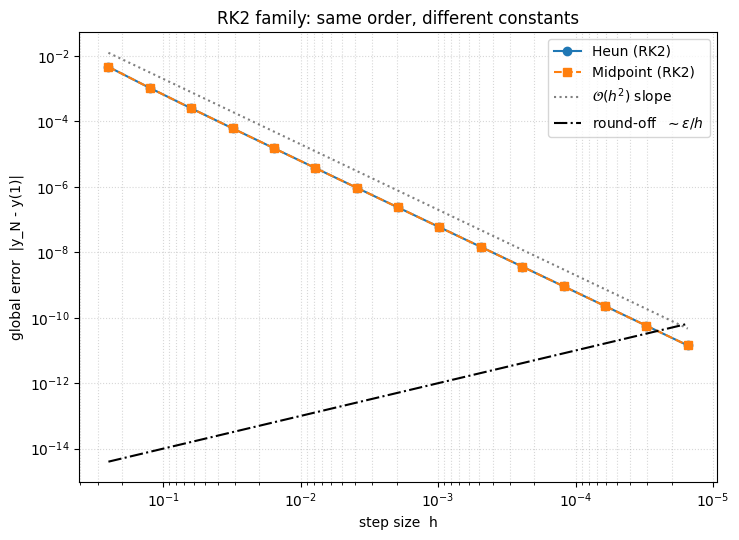

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.loglog(df["h"], df["err_Heun"], "o-",  label="Heun (RK2)")
ax.loglog(df["h"], df["err_Mid"],  "s--", label="Midpoint (RK2)")

# reference O(h^2) and round-off ~ eps / h
href = df["h"].to_numpy()
ax.loglog(href, 0.20 * href**2, ":",  color="gray",  label=r"$\mathcal{O}(h^2)$ slope")
ax.loglog(href, 1e-15 / href,   "-.", color="black", label=r"round-off  $\sim \varepsilon/h$")

ax.set_xlabel("step size  h")
ax.set_ylabel("global error  |y_N - y(1)|")
ax.set_title("RK2 family: same order, different constants")
ax.invert_xaxis()
ax.grid(True, which="both", ls=":", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **두 RK2 의 인접 비율이 모두 $\to 4$.** $h$ 를 절반으로 줄이면 오차가 약 $1/4$ — 정확히 $\mathcal{O}(h^2)$ 의
   증거. Heun 과 Midpoint 의 차이는 *주도 오차 계수* 뿐 (Heun 이 미세하게 작음).
2. **경험 기울기 $\widehat{p} \approx 2.00$.** 절단오차가 지배하는 영역에서 log–log polyfit 이 깔끔하게 $+2$.
3. **둘이 *교차하지 않음*.** 차수가 같아도 상수가 다르므로 한쪽이 일관되게 더 작거나 큰 오차를 줌.
   이는 *RK 가족의 자유도* 가 만들어내는 *섬세한 trade-off* 를 보여주는 예.
4. **Round-off floor.** $h \lesssim 10^{-4}$ 부터는 $\varepsilon / h$ 로 다시 올라감 — Day 27 의 *Taylor 1차*
   에서 봤던 *U 자형* 과 본질적으로 동일한 구조.

> **결론**: RK2 는 *도함수 없는 Taylor 2차* — 두 표준 선택 (Heun / Midpoint) 은 *같은 차수의 형제*이며,
> 차이는 *상수*에 있을 뿐 *차수*에는 없다.

**다음 문제로의 연결**: 같은 *함수 평가 트릭* 을 4-stage 로 확장하면 *Taylor 4차에 해당하는* 고전 RK4 가 된다.
도함수 없이 4차를 얻는 *놀라움* 과 *비용 trade-off* 를 Problem 2 에서 확인한다.
